In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.cm.get_cmap('RdYlBu')


pd.set_option('display.max_rows', 200)

### Load Recast Data

In [2]:
# inputFiles = ['../CMS-EXO-20-004/spin0-results-for-database.pcl', '../CMS-EXO-20-004/pseudoscalar_comp_add.pcl']
inputFiles = ['/home/camila/scalar_550_150_cms_exo_20_004.pcl']
dfs = [pd.read_pickle(i) for i in inputFiles]
# inputFilesNew = ['../CMS-EXO-20-004/scalar_nocut.pcl']
# dfsNew = [pd.read_pickle(i) for i in inputFilesNew]
recastData = pd.concat(dfs, ignore_index=True)
# recastDataNew = pd.concat(dfsNew, ignore_index=True)

### Get all model points

In [3]:
models = []
mCols = ['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', '$g_{DM}$', '$g_{q}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

1 models loaded.


### Get models parameters

In [4]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Coupling': 'Scalar', 'Mode': 'DM+QCDjets', '$m_{med}$': 550.0, '$m_{DM}$': 150.0, '$g_{DM}$': 1.0, '$g_{q}$': 1.0}
Coupling = Scalar
Mode = DM+QCDjets
$g_{DM}$ = 1.0
$g_{q}$ = 1.0


In [5]:
recastData[(recastData['Coupling']=='Scalar')&(recastData['$m_{med}$']==750)]

,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,bin_280.0_310.0_ErrorPlus,bin_280.0_310.0_ErrorMinus,bin_310.0_340.0,bin_310.0_340.0_ErrorPlus,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)


In [6]:
paramFilter = {
    'Mode' : 'DM+QCDjets',
    '$m_{med}$' : 550.,
    '$m_{DM}$' : 150.,
    '$g_{DM}$' : 1.,
    '$g_{q}$' : 1.,
    'Data-takingperiod' : 2017
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]
# dfModelNew = recastDataNew[(recastDataNew[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

### Filter parameters

The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Auxiliar functions for plotting

In [7]:
def getBins(dfModel,rightBin = 2000.):
    
    bins = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and not 'Error' in c)}
    binsError = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and 'ErrorPlus' in c)}    
    binCenter = (np.array(list(bins.values()))+np.diff(list(bins.values())+[rightBin])/2).tolist()    
    binLeft = [bins[c] for c in bins]+[rightBin] 
    
    return bins,binsError,binCenter,binLeft


def getEfficiencies(dfSingle, bins, binsError):
    
    xsec = dfSingle['Total xsec (pb)'].iloc[0]
    lumi = dfSingle['Luminosity (1/fb)'].iloc[0]
    eff = {c: dfSingle[c].iloc[0]/(xsec*1e3*lumi) for c in bins}
    ns = {c: dfSingle[c].iloc[0] for c in bins}
    nsErr = {c : dfSingle[c].iloc[0] for c in binsError}
    effErr = {}
    for c in bins:
        if ns[c] == 0:
            effErr[f'{c}_Error'] = 0
        else:
            effErr[f'{c}_Error'] = nsErr[f'{c}_ErrorPlus']*eff[c]/ns[c]
    
    return eff, effErr

### Plot Efficiencies

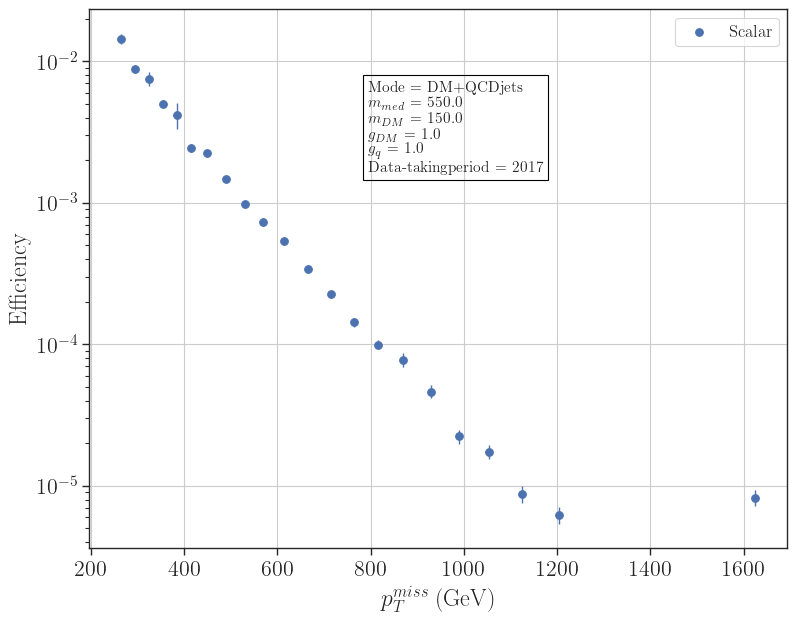

In [8]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(figsize=(9,7))

data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    


for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    

    ax.scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax.errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

ax.text(.4, 0.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax.set_ylabel('Efficiency')
ax.legend()

ax.legend(fontsize='12')
ax.grid(True)
ax.set_xlabel(r'$p_{T}^{miss}$ (GeV)')
ax.set_yscale('log')

plt.savefig('/home/camila/eff-scalar-150-550-after.png')

plt.show()

In [50]:
dfModel.T

,1018
Coupling,Scalar
Mode,DM+QCDjets
$m_{med}$,650.0
$m_{DM}$,300.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,14.516986
bin_250.0_280.0_ErrorPlus,0.94803
bin_250.0_280.0_ErrorMinus,0.94803
bin_280.0_310.0,10.992834


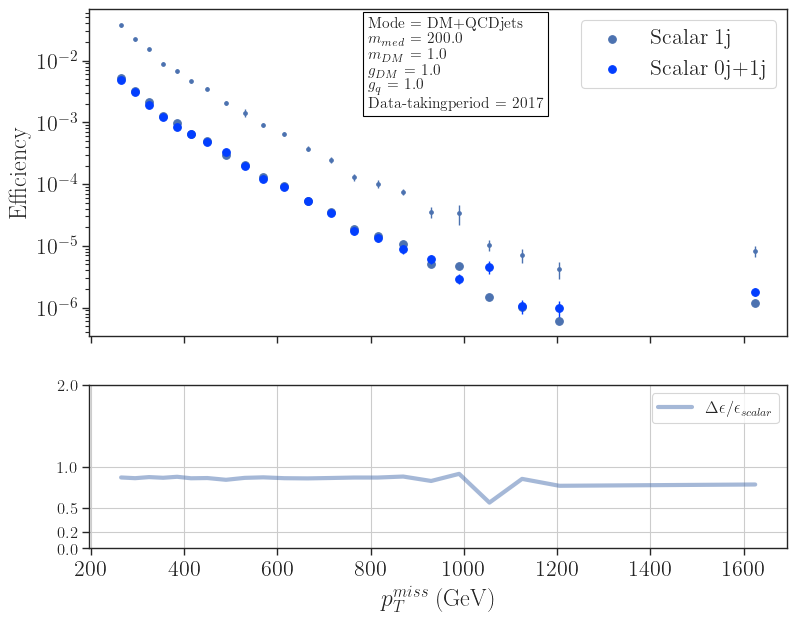

In [13]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))

data = pd.DataFrame(columns=['Scalar'])
dataError = pd.DataFrame(columns=['Scalar'])
colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

dataNew = pd.DataFrame(columns=['Scalar'])
dataErrorNew = pd.DataFrame(columns=['Scalar'])
colorsNew = {label : sns.color_palette('bright')[i] for i,label in enumerate(dataNew.keys())}   

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff/7, s=30, color=colors[label], label=label+' 1j')
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])
    
    
for label in dfModelNew['Coupling']:
    
    dfSingle = dfModelNew[dfModelNew['Coupling'] == label]
    dataNew[label], dataErrorNew[label] = getEfficiencies(dfSingle, bins, binsError)
    
    eff = np.array([dataNew[label][c] for c in bins])
    effErr = np.array([dataErrorNew[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colorsNew[label], label=label+' 0j+1j')
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colorsNew[label])
    
diff = np.abs(data - dataNew)

relDiff = diff/data
relDiff = relDiff.replace(np.nan, 0)

diffError = np.array(diff)/np.sqrt(dataError**2 + dataErrorNew**2)
diffError = diffError.replace(np.nan, 0)

# diffNew = np.abs(dataNew.Axial - dataNew.Vector)

# relDiffNew = diffNew/dataNew.Axial
# relDiffNew = relDiffNew.replace(np.nan, 0)

# diffErrorNew = np.array(diffNew)/np.sqrt(dataErrorNew.Axial**2 + dataErrorNew.Vector**2)
# diffErrorNew = diffErrorNew.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{scalar}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
# # ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
# #            label=label2)

# ax[1].plot(binCenter, relDiffNew, color=colorsNew[label], linewidth=3., label=label1+' (new)', alpha=.5)
# # ax[1].plot(binCenter, diffErrorNew, color=colorsNew[label], linewidth=3., linestyle='--', 
# #            label=label2+' (new)')

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()

In [8]:
data

,Scalar
bin_250.0_280.0,0.037197
bin_280.0_310.0,0.022211
bin_310.0_340.0,0.015200
bin_340.0_370.0,0.008984
bin_370.0_400.0,0.006870
bin_400.0_430.0,0.004602
bin_430.0_470.0,0.003501
bin_470.0_510.0,0.002065
bin_510.0_550.0,0.001441
bin_550.0_590.0,0.000915


In [9]:
dataNew

,Scalar
bin_250.0_280.0,4.897252e-03
bin_280.0_310.0,3.120922e-03
bin_310.0_340.0,1.932701e-03
bin_340.0_370.0,1.218004e-03
bin_370.0_400.0,8.474248e-04
bin_400.0_430.0,6.514993e-04
bin_430.0_470.0,4.858944e-04
bin_470.0_510.0,3.310513e-04
bin_510.0_550.0,1.967748e-04
bin_550.0_590.0,1.190083e-04


In [12]:
0.037197/4.897252e-03

7.595484161321492

In [11]:
(data/dataNew).mean()

Scalar    6.968328
dtype: float64

In [13]:
1/0.3342525

2.9917502486892396

In [5]:
3.751748*3

11.255244000000001

In [7]:
1.981828*3

5.9454839999999995

In [8]:
1/0.787631

1.2696300678871197

In [11]:
1/0.2977582

3.3584297594491104

In [12]:
1/0.7294957

1.3708099992912912

In [10]:
0.011870*(41.5/137)

0.0035956569343065696